# HarvestStat Data Analysis - Somalia

## Validation with FAOSTAT and CHIRPS Precipitation

### Gu+Deyr season

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_98228/1009184550.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')


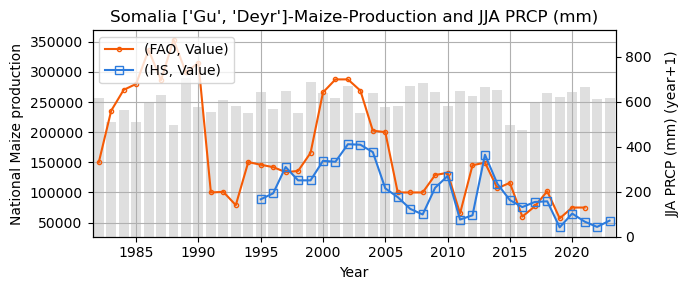

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_98228/1009184550.py:117: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')


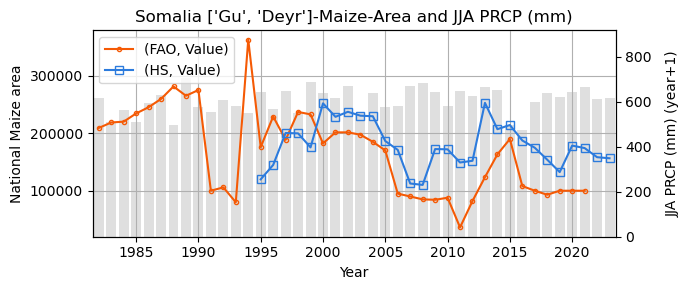

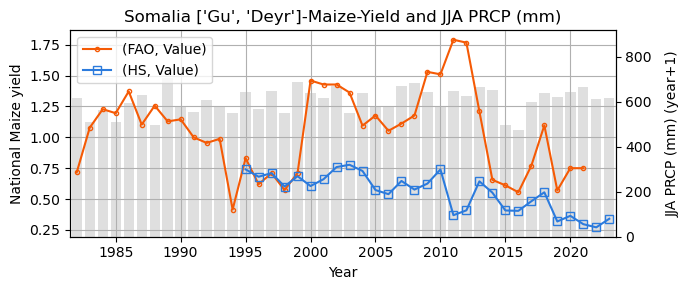

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_98228/1009184550.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')


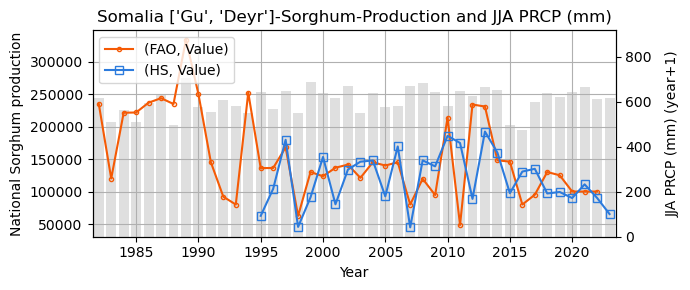

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_98228/1009184550.py:117: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')


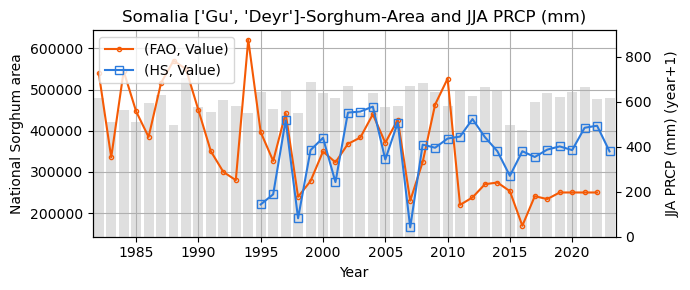

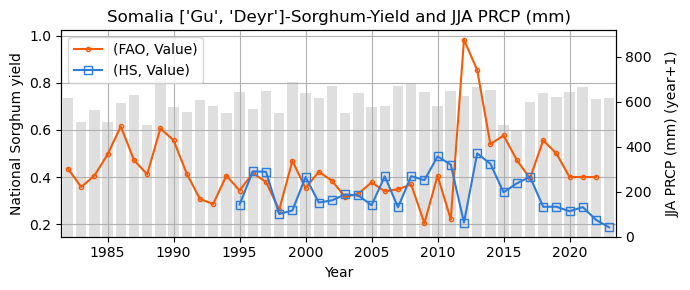

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import proplot as pplot
# Load Crop Data ------------------------------------- #
css = [[['Gu','Deyr'],'Maize','Maize (corn)'],
     [['Gu','Deyr'],'Sorghum','Sorghum']]
country_name = 'Somalia'
for cs in css:
    season_name = cs[0] 
    product_name_fdw = cs[1] 
    product_name_fao  = cs[2]
    shape_code, prcp_start_month, prcp_season_name, prcp_year_offset = 'ET2019A0', 6, 'JJA PRCP (mm)', +1
    
    
    # HarvestStat
    df = pd.read_csv('../public/hvstat_africa_data_v1.1.csv', index_col=0)
    df = df.loc[
        (df['country'] == country_name) &
        np.isin(df['season_name'],season_name) &
        (df['product'].isin([product_name_fdw]))
    ].copy()
    df['year'] = df.harvest_year
    df['Value'] = df['production']
    data_hs = df[['year','Value']].groupby(by = ['year']).sum()
    data_hs.loc[data_hs.Value < (data_hs.Value.mean())*.01] = np.nan
    # FAO-STAT
    df = pd.read_csv('../data/crop/adm_fao_stat.csv', index_col=0)
    df['year'] = df.Year
    df.loc[df.Element=='Area harvested','Element'] = 'Area'
    
    data_fao = df[
        (df['Area'] == country_name) &
        (df['Item'] == product_name_fao) &
        (df['Element'] == 'Production')
    ].set_index('year')['Value']
    # Merge
    data = pd.concat([data_fao,data_hs], axis=1, keys=['FAO','HS']).sort_index()
    data = data.reindex(np.array(range(1982,2024)))
    # ---------------------------------------------------- #
    # Load precipitation --------------------------------- #
    fn = '../data/prcp_chirps-v2.hdf'
    prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')
    prcp_nat.index = prcp_nat.index.map(lambda x: x.replace(day=1))
    prcp_nat.name = 'PRCP'
    prcp_nat.index = prcp_nat.index + pd.DateOffset(years=prcp_year_offset)
    # Forward rolling summation
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=3)   # Forward Rolling Window
    prcp_nat = prcp_nat.rolling(window=indexer, min_periods=3).sum()
    prcp_nat = prcp_nat[prcp_nat.index.month == prcp_start_month]                      # Start month
    prcp_nat = prcp_nat.groupby(prcp_nat.index.year).sum()
    prcp_label = prcp_season_name
    
    # ---------------------------------------------------- #
    # Comparison with Precipitation ---------------------- #
    fig, ax1 = plt.subplots(figsize=(7,3))
    fig.set_facecolor('white')
    data.plot(ax=ax1, grid=True, markerfacecolor='None',color=['#F55A05','#2C7BDD'])
    marker = ['.','s']
    for i, line in enumerate(ax1.get_lines()):
        line.set_marker(marker[i])
    # years = data.index
    # ax1.set_xticks(years)
    # ax1.set_xticklabels(['%02d'% yr for yr in np.mod(years,100)])
    ax1.set_xlim([data.index[0]-0.5, data.index[-1]+0.5])
    ax1.set_xlabel('Year')
    ax1.set_ylabel('National '+product_name_fdw+' production')
    ax1.patch.set_facecolor('white')
    # Precipitation
    year, value = prcp_nat.index, prcp_nat.values
    ax2 = ax1.twinx()
    plt.bar(year, value, alpha=.25, color='grey')
    ax2.set_ylim([0, value.max()*1.3])
    ax2.set_ylabel(prcp_label + ' (year+%d)'%prcp_year_offset, labelpad=10)
    ax2.grid(False)
    ax1.set_zorder(1)  
    ax1.patch.set_visible(False)  # prevents ax1 from hiding ax2
    ax1.legend(loc='upper left')
    
    title = f'{country_name} {season_name}-{product_name_fdw}-Production and {prcp_label}'
    ax1.set_title(title)
    fig.tight_layout()
    plt.show()
    
    data_prod = data
    # ---------------------------------------------------- #
    
    
    
    # HarvestStat
    df = pd.read_csv('../public/hvstat_africa_data_v1.1.csv', index_col=0)
    df = df.loc[
        (df['country'] == country_name) &
        np.isin(df['season_name'],season_name) &
        (df['product'].isin([product_name_fdw]))
    ].copy()
    df['year'] = df.harvest_year
    df['Value'] = df['area']
    data_hs = df[['year','Value']].groupby(by = ['year']).sum()
    data_hs.loc[data_hs.Value < (data_hs.Value.mean())*.01] = np.nan
    # FAO-STAT
    df = pd.read_csv('../data/crop/adm_fao_stat.csv', index_col=0)
    df['year'] = df.Year
    df.loc[df.Element=='Area harvested','Element'] = 'Area'
    
    data_fao = df[
        (df['Area'] == country_name) &
        (df['Item'] == product_name_fao) &
        (df['Element'] == 'Area')
    ].set_index('year')['Value']
    # Merge
    data = pd.concat([data_fao,data_hs], axis=1, keys=['FAO','HS']).sort_index()
    data = data.reindex(np.array(range(1982,2024)))
    # ---------------------------------------------------- #
    # Load precipitation --------------------------------- #
    fn = '../data/prcp_chirps-v2.hdf'
    prcp_nat = pd.read_hdf(fn)[shape_code].resample('1M').agg('sum')
    prcp_nat.index = prcp_nat.index.map(lambda x: x.replace(day=1))
    prcp_nat.name = 'PRCP'
    prcp_nat.index = prcp_nat.index + pd.DateOffset(years=prcp_year_offset)
    # Forward rolling summation
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=3)   # Forward Rolling Window
    prcp_nat = prcp_nat.rolling(window=indexer, min_periods=3).sum()
    prcp_nat = prcp_nat[prcp_nat.index.month == prcp_start_month]                      # Start month
    prcp_nat = prcp_nat.groupby(prcp_nat.index.year).sum()
    prcp_label = prcp_season_name
    
    # ---------------------------------------------------- #
    # Comparison with Precipitation ---------------------- #
    fig, ax1 = plt.subplots(figsize=(7,3))
    fig.set_facecolor('white')
    data.plot(ax=ax1, grid=True, markerfacecolor='None',color=['#F55A05','#2C7BDD'])
    marker = ['.','s']
    for i, line in enumerate(ax1.get_lines()):
        line.set_marker(marker[i])
    # years = data.index
    # ax1.set_xticks(years)
    # ax1.set_xticklabels(['%02d'% yr for yr in np.mod(years,100)])
    ax1.set_xlim([data.index[0]-0.5, data.index[-1]+0.5])
    ax1.set_xlabel('Year')
    ax1.set_ylabel('National '+product_name_fdw+' area')
    ax1.patch.set_facecolor('white')
    # Precipitation
    year, value = prcp_nat.index, prcp_nat.values
    ax2 = ax1.twinx()
    plt.bar(year, value, alpha=.25, color='grey')
    ax2.set_ylim([0, value.max()*1.3])
    ax2.set_ylabel(prcp_label + ' (year+%d)'%prcp_year_offset, labelpad=10)
    ax2.grid(False)
    ax1.set_zorder(1)  
    ax1.patch.set_visible(False)  # prevents ax1 from hiding ax2
    ax1.legend(loc='upper left')
    
    title = f'{country_name} {season_name}-{product_name_fdw}-Area and {prcp_label}'
    ax1.set_title(title)
    fig.tight_layout()
    plt.show()
    
    data_area = data
    # ---------------------------------------------------- #
    
    
    
    # ---------------------------------------------------- #
    # Comparison with Precipitation ---------------------- #
    
    data = data_prod/data_area
    
    fig, ax1 = plt.subplots(figsize=(7,3))
    fig.set_facecolor('white')
    data.plot(ax=ax1, grid=True, markerfacecolor='None',color=['#F55A05','#2C7BDD'])
    marker = ['.','s']
    for i, line in enumerate(ax1.get_lines()):
        line.set_marker(marker[i])
    # years = data.index
    # ax1.set_xticks(years)
    # ax1.set_xticklabels(['%02d'% yr for yr in np.mod(years,100)])
    ax1.set_xlim([data.index[0]-0.5, data.index[-1]+0.5])
    ax1.set_xlabel('Year')
    ax1.set_ylabel('National '+product_name_fdw+' yield')
    ax1.patch.set_facecolor('white')
    # Precipitation
    year, value = prcp_nat.index, prcp_nat.values
    ax2 = ax1.twinx()
    plt.bar(year, value, alpha=.25, color='grey')
    ax2.set_ylim([0, value.max()*1.3])
    ax2.set_ylabel(prcp_label + ' (year+%d)'%prcp_year_offset, labelpad=10)
    ax2.grid(False)
    ax1.set_zorder(1)  
    ax1.patch.set_visible(False)  # prevents ax1 from hiding ax2
    ax1.legend(loc='upper left')
    
    title = f'{country_name} {season_name}-{product_name_fdw}-Yield and {prcp_label}'
    ax1.set_title(title)
    fig.tight_layout()
    plt.show()
    # ---------------------------------------------------- #